# Coursework - Rowan d'Auria (rd761)

### TODO
- Data Exploration

## Data Exploration
> _Become one with the data_

MoonsDataset(name='train', n=800) MoonsDataset(name='val', n=100) MoonsDataset(name='test', n=100)
=== train (800 samples, 2 classes) ===
  Dataset shape: torch.Size([800, 2])
  Class counts: {0: 385, 1: 415}
  x1: mean=0.521, std=0.874, range=[-1.127, 2.067]
  x2: mean=0.231, std=0.491, range=[-0.610, 1.201]
  class_0: mean=[0.001268340740352869, 0.6216179728507996], std=[0.717052698135376, 0.3202870488166809]
  class_1: mean=[1.0032110214233398, -0.13077937066555023], std=[0.7164219617843628, 0.31061533093452454]

  Duplicates: 0, NaNs: 0
  Correlation(x1, x2): -0.4347

=== val (100 samples, 2 classes) ===
  Dataset shape: torch.Size([100, 2])
  Class counts: {0: 56, 1: 44}
  x1: mean=0.461, std=0.796, range=[-1.003, 2.029]
  x2: mean=0.334, std=0.541, range=[-0.579, 1.078]
  class_0: mean=[0.05057208612561226, 0.7256950736045837], std=[0.6229149699211121, 0.28358083963394165]
  class_1: mean=[0.9824522137641907, -0.16392913460731506], std=[0.6777079105377197, 0.34579598903656006]

 

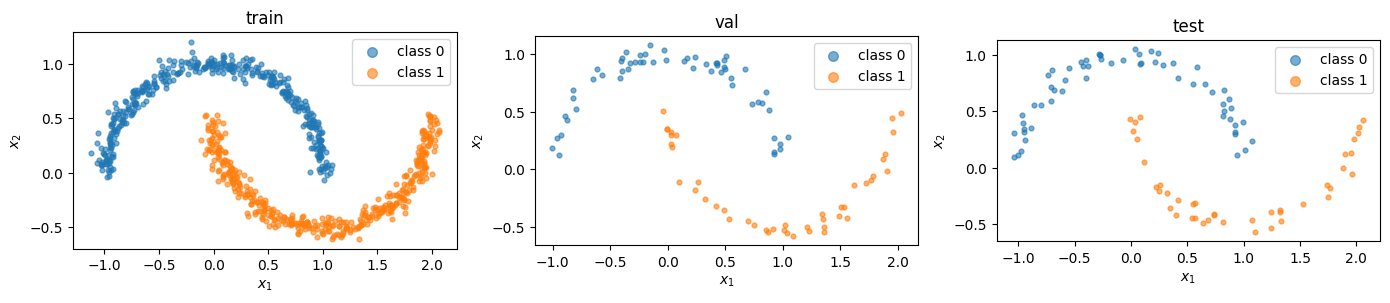

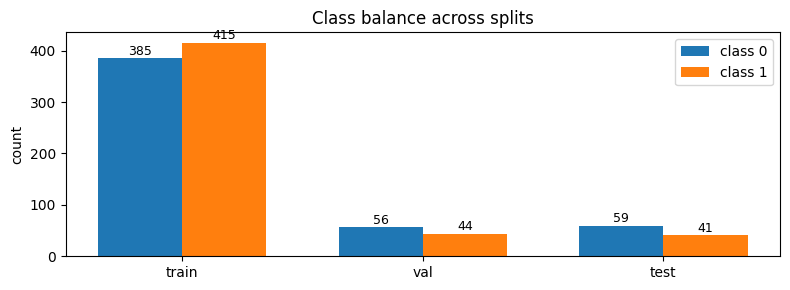

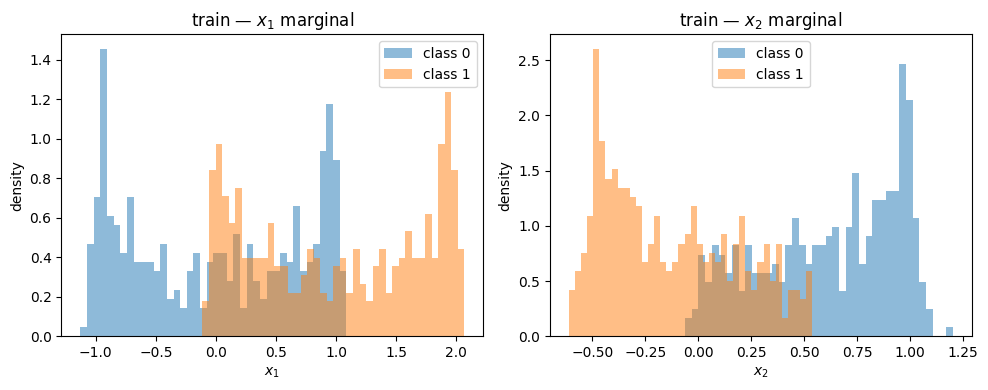

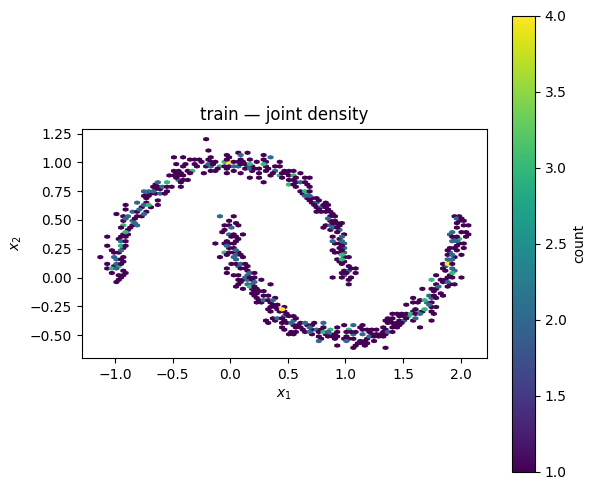

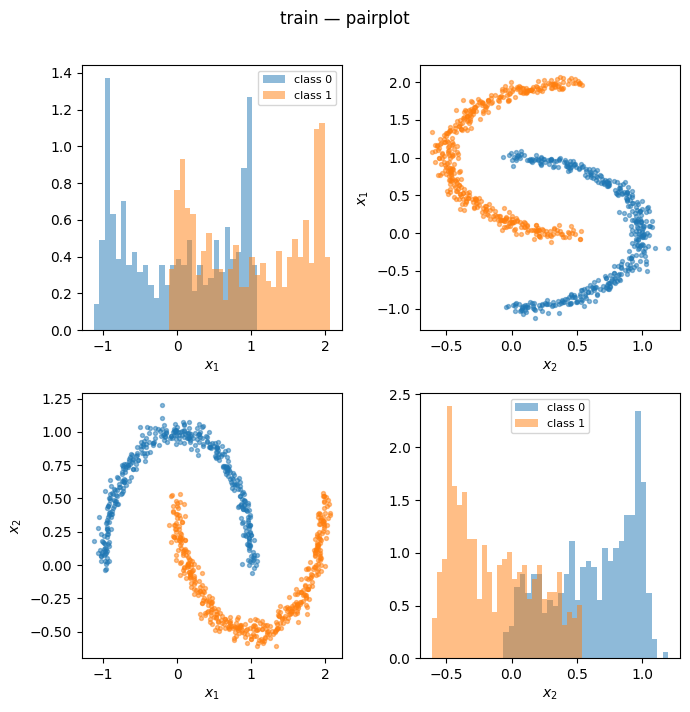

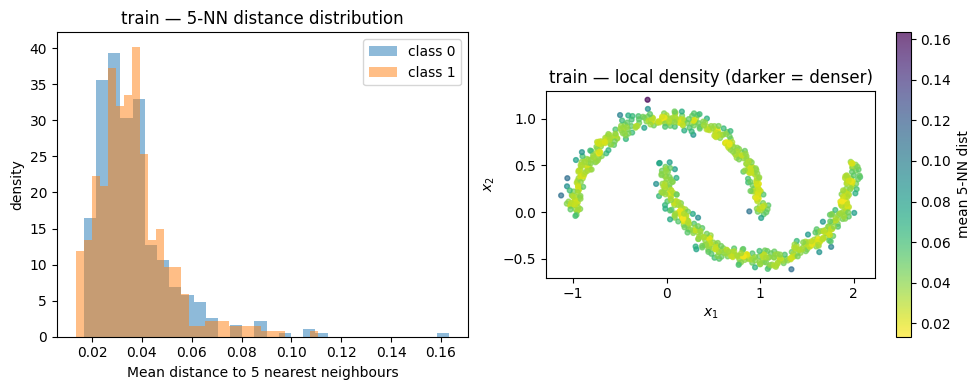

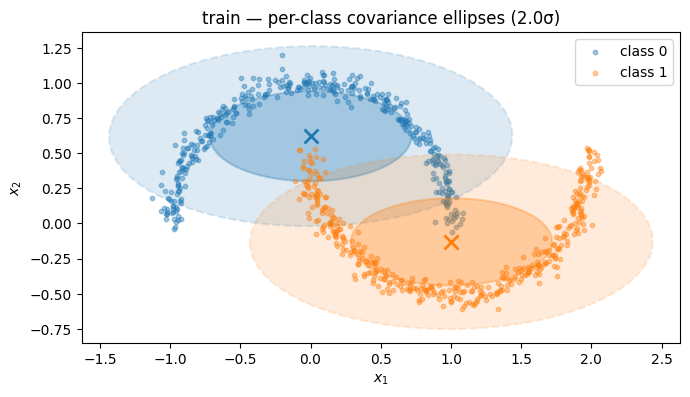

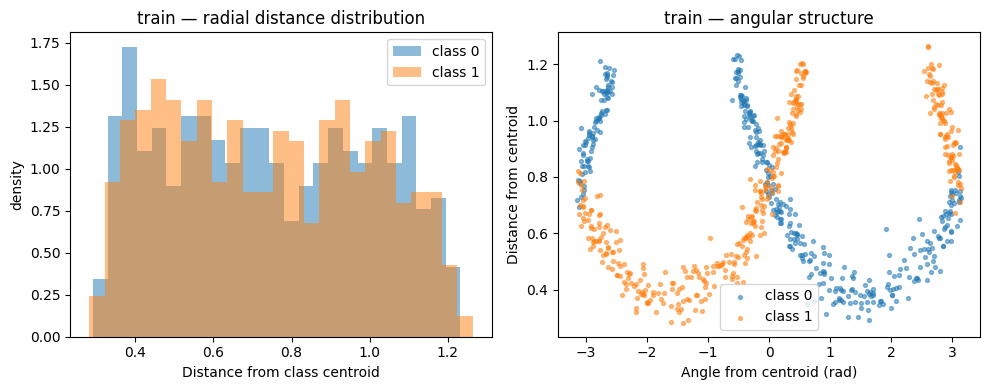

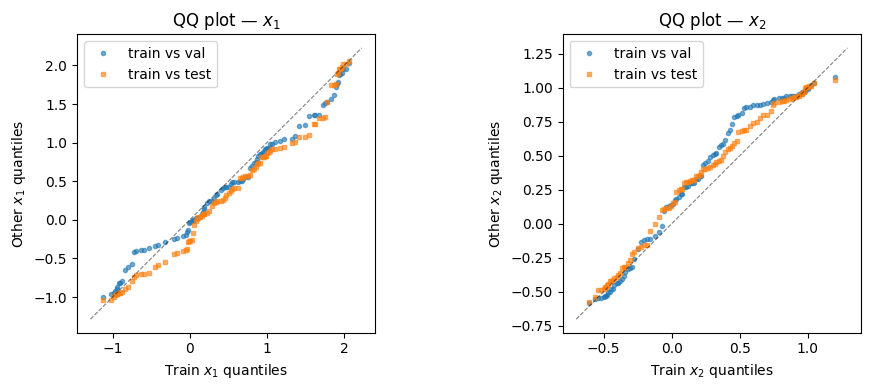

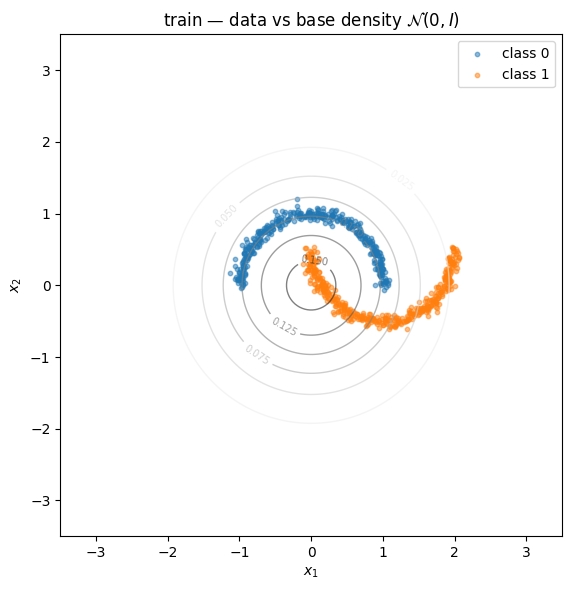

In [17]:
from flows import *

# Load all splits
splits = MoonsSplits.load("data")
print(splits.train, splits.val, splits.test)

# --- Full statistical report (now includes KS tests) ---
full_report(splits)

# --- Visualisations ---

# 1. Scatter plots of each split side-by-side
scatter_splits(splits)

# 2. Class balance across splits
class_balance_bar(splits.train, splits.val, splits.test)

# 3. Marginal histograms (per-class) for training data
marginal_histograms(splits.train)

# 4. Joint density estimate
joint_kde(splits.train)

# 5. Pairplot
pairplot(splits.train)

# 6. k-NN distances — local density variation
knn_distances(splits.train, k=5)

# 7. Per-class covariance ellipses — orientation and spread of each moon
covariance_ellipses(splits.train)

# 8. Radial distance from class centroids — reveals arc structure
radial_from_centroids(splits.train)

# 9. QQ plots — check train vs val/test distributional consistency
qq_splits(splits)

# 10. Base density overlay — how far the data is from N(0,I)
_ = base_density_overlay(splits.train)

### Data Exploration Observations
- Interesting grouping
- Add more!!!

## Q1 - A Mini Normalizing Flow



In this coursework you will implement and train an affine coupling flow (chapter 16 of Prince, *Understanding Deep Learning*) on a 2D dataset.

### (a)

Implement an affine coupling transform for a 2D vector $h = [h_1 \; h_2]^\top$. Implement this in PyTorch. A single coupling layer keeps one component fixed and transforms the other:

$$h_1' = h_1, \qquad h_2' = h_2 \odot \exp[s[h_1]] + t[h_1],$$

where $s[\cdot]$ and $t[\cdot]$ are learned functions, and $\odot$ denotes elementwise multiplication. The $\exp[\cdot]$ is also applied elementwise. In this coursework, implement $s[\cdot]$ and $t[\cdot]$ using a single MLP applied to the masked input, with architecture

$$\text{Linear}(D \to H) \;\to\; \text{ReLU} \;\to\; \text{Linear}(H \to 2D),$$

then split the output into $s[\cdot]$ and $t[\cdot]$. Use at most `hidden=128` and at most `n_layers=8` in your submitted model. For numerical stability you should bound the scale output using $s \leftarrow \tanh[s]$.

Implement both directions:

- the forward map $f[z]$ used for sampling (base $\to$ data), and
- the inverse map $f^{-1}[x]$ used for evaluating $\log p[x]$ (data $\to$ base).

Your code must return both the transformed output and the log-determinant of the Jacobian for that direction.

### (b)

Build a flow by stacking $K$ coupling layers with alternating masks (each dimension should be transformed in some layers). Let the base density be standard normal $p[z] = \mathcal{N}(0, I)$. Implement a function that evaluates $\log p[x]$ for a batch of points.

Below we define an `AffineCouplingLayer` that keeps one component fixed and transforms the other via an internal MLP, and a `Flow` that stacks $K$ such layers with alternating masks.

In [18]:
from flows import AffineCouplingLayer, Flow

### Q1(c) - Correctness Checks

Two checks:

1. **Invertibility**: for every point in `data/moons_train.csv`, compute $z = f^{-1}[x]$, reconstruct $\hat{x} = f[z]$, and report the maximum absolute reconstruction error over the full training set.

2. **Log-det check**: using the first example in `data/moons_train.csv`, numerically estimate the Jacobian of $f^{-1}[\cdot]$ by central differences with step size $\epsilon = 10^{-4}$, and compare $\log|\det J|$ to the analytic log-det. Report the absolute error.

Save a two-panel diagnostic figure to `figs/Figure1c.pdf`.

$$
J = \begin{bmatrix}
\frac{\partial z_1}{\partial x_1} & \frac{\partial z_1}{\partial x_2} \\
\frac{\partial z_2}{\partial x_1} & \frac{\partial z_2}{\partial x_2}
\end{bmatrix}
$$

Invertibility max absolute error: 9.54e-07
Analytic log|det J|:  0.432602
Numerical log|det J|: 0.435983
Log-det absolute error: 3.38e-03


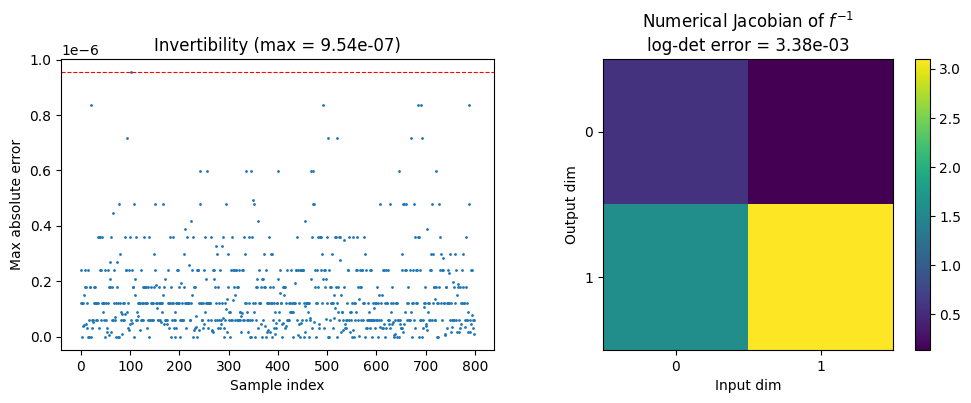

Saved results.json and figs/Figure1c.pdf


In [19]:
import os
import json
import torch
import matplotlib.pyplot as plt

# Load training data
splits = MoonsSplits.load("data")
x_train = splits.train.x

# Instantiate an untrained flow for the correctness checks
torch.manual_seed(42)
flow = Flow(dim=2, hidden=128, n_layers=8)

# --- Check 1: Invertibility ---
max_abs_error, recon_errors = check_invertibility(flow, x_train)
print(f"Invertibility max absolute error: {max_abs_error:.2e}")

# --- Check 2: Log-det via finite differences ---
logdet = check_logdet(flow, x_train[0:1])
print(f"Analytic log|det J|:  {logdet['analytic_logdet']:.6f}")
print(f"Numerical log|det J|: {logdet['numerical_logdet']:.6f}")
print(f"Log-det absolute error: {logdet['abs_error']:.2e}")

# --- Figure 1c: two-panel diagnostic ---
os.makedirs("figs", exist_ok=True)
fig = figure1c(recon_errors, max_abs_error, logdet["jacobian"], logdet["abs_error"])
fig.savefig("figs/Figure1c.pdf")
plt.show()

# --- Save to results.json ---
results = {
    "correctness": {
        "invertibility_max_abs_error": max_abs_error,
        "logdet_finite_diff_abs_error": logdet["abs_error"],
    }
}

with open("results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved results.json and figs/Figure1c.pdf")

### Q1c) Observations

- Very interesting in in left figure how the invertibility errors fall at distinct levels, thy aren't completely random. What does this mean for the source of the error, is it floating point arithmetic errors?

## Q2 - Training Pipeline


### (a) Tiny subset training

Use exactly the first 128 rows of `data/moons_train.csv` as the tiny subset. Train the flow on that subset, plot the loss curve, and record the final tiny-set NLL.

In [20]:
SEED = 42
N_TINY_STEPS = 10000
LR_TINY = 1e-3

x_tiny = x_train[:128]
x_val = splits.val.x
x_test = splits.test.x

torch.manual_seed(SEED)
flow_tiny = Flow(dim=2, hidden=16, n_layers=2)
optimizer_tiny = torch.optim.Adam(flow_tiny.parameters(), lr=LR_TINY)

tiny_losses = []
tiny_val_losses = []

for step in range(N_TINY_STEPS):
    # put the flow model in training mode
    flow_tiny.train()
    # calculate current loss, "loss" is a torch tensor
    loss = -flow_tiny.log_prob(x_tiny).mean()
    # remove any old gradients stored on the model
    optimizer_tiny.zero_grad()
    # calculate gradients of model weights according to the loss
    loss.backward()
    # use parameter gradients to update model parameters
    optimizer_tiny.step()
    # record the loss for plotting
    tiny_losses.append(loss.item())

    # Validation loss every step (cheap: only 100 points)
    flow_tiny.eval()
    with torch.no_grad():
        val_loss = -flow_tiny.log_prob(x_val).mean().item()
    tiny_val_losses.append(val_loss)

    if (step + 1) % 500 == 0:
        print(f"Step {step+1}/{N_TINY_STEPS}, NLL: {loss.item():.4f}, Val NLL: {val_loss:.4f}")

# Final NLL evaluated on the full tiny set
flow_tiny.eval()
with torch.no_grad():
    tinyset_final_nll = -flow_tiny.log_prob(x_tiny).mean().item()
print(f"\nFinal tiny-set NLL: {tinyset_final_nll:.4f}")



Step 500/10000, NLL: 1.7263, Val NLL: 1.7170
Step 1000/10000, NLL: 1.5626, Val NLL: 1.7188
Step 1500/10000, NLL: 1.4897, Val NLL: 1.7657
Step 2000/10000, NLL: 1.4323, Val NLL: 1.7769
Step 2500/10000, NLL: 1.3915, Val NLL: 1.7738
Step 3000/10000, NLL: 1.3707, Val NLL: 1.8056
Step 3500/10000, NLL: 1.3624, Val NLL: 1.8442
Step 4000/10000, NLL: 1.3566, Val NLL: 1.8462
Step 4500/10000, NLL: 1.3524, Val NLL: 1.8508
Step 5000/10000, NLL: 1.3490, Val NLL: 1.8573
Step 5500/10000, NLL: 1.3441, Val NLL: 1.8631
Step 6000/10000, NLL: 1.3401, Val NLL: 1.8615
Step 6500/10000, NLL: 1.3369, Val NLL: 1.8646
Step 7000/10000, NLL: 1.3338, Val NLL: 1.8654
Step 7500/10000, NLL: 1.3313, Val NLL: 1.8658
Step 8000/10000, NLL: 1.3302, Val NLL: 1.8779
Step 8500/10000, NLL: 1.3285, Val NLL: 1.8762
Step 9000/10000, NLL: 1.3274, Val NLL: 1.8834
Step 9500/10000, NLL: 1.3264, Val NLL: 1.8840
Step 10000/10000, NLL: 1.3253, Val NLL: 1.8830

Final tiny-set NLL: 1.3253


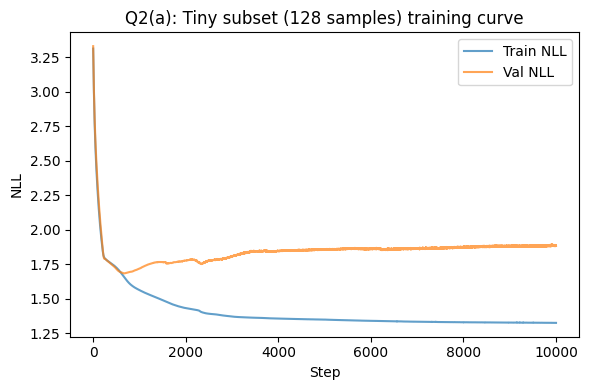

Saved figs/Figure2a.pdf


In [21]:
# --- Figure 2a ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(tiny_losses, label="Train NLL", alpha=0.7)
ax.plot(tiny_val_losses, label="Val NLL", alpha=0.7)
ax.set_xlabel("Step")
ax.set_ylabel("NLL")
ax.set_title("Q2(a): Tiny subset (128 samples) training curve")
ax.legend()
fig.tight_layout()
fig.savefig("figs/Figure2a.pdf")
plt.show()
print("Saved figs/Figure2a.pdf")

### (b) + (c) Full training

Train on the full `data/moons_train.csv` with:
- Cosine annealing LR schedule
- Validation loss tracking against `data/moons_val.csv`
- Final checkpoint saved to `checkpoints/flow_full.pt`
- Training log saved to `logs/training_curves.json`

Record final train, validation, and test NLL in `results.json`.

Step 500/5000, Train NLL: 1.5576, Val NLL: 1.5433
Step 1000/5000, Train NLL: 1.0561, Val NLL: 1.0537
Step 1500/5000, Train NLL: 0.6365, Val NLL: 0.5891
Step 2000/5000, Train NLL: 0.4934, Val NLL: 0.4901
Step 2500/5000, Train NLL: 0.4018, Val NLL: 0.4694
Step 3000/5000, Train NLL: 0.3574, Val NLL: 0.4671
Step 3500/5000, Train NLL: 0.3333, Val NLL: 0.4704
Step 4000/5000, Train NLL: 0.3211, Val NLL: 0.4786
Step 4500/5000, Train NLL: 0.3163, Val NLL: 0.4827
Step 5000/5000, Train NLL: 0.3155, Val NLL: 0.4836

Final Train NLL: 0.3155
Final Val NLL:   0.4836
Final Test NLL:  0.4499
Saved checkpoints/flow_full.pt
Saved logs/training_curves.json


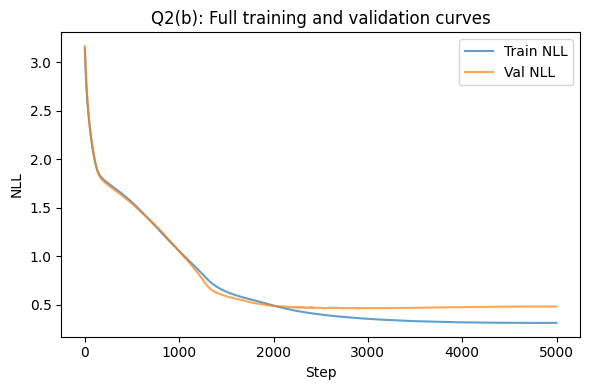

Saved figs/Figure2c.pdf
Updated results.json with training metrics


In [22]:
N_FULL_STEPS = 5000
LR = 5e-5
import numpy as np

# Load validation and test data
val_data = np.loadtxt("data/moons_val.csv", delimiter=",", skiprows=1)
test_data = np.loadtxt("data/moons_test.csv", delimiter=",", skiprows=1)
x_val = torch.tensor(val_data[:, :2], dtype=torch.float32)
x_test = torch.tensor(test_data[:, :2], dtype=torch.float32)

# Fresh flow for full training
torch.manual_seed(SEED)
flow_full = Flow(dim=2, hidden=128, n_layers=8)
optimizer_full = torch.optim.Adam(flow_full.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_full, T_max=N_FULL_STEPS)

full_losses = []
full_val_losses = []

for step in range(N_FULL_STEPS):
    flow_full.train()
    loss = -flow_full.log_prob(x_train).mean()
    optimizer_full.zero_grad()
    loss.backward()
    optimizer_full.step()
    scheduler.step()

    full_losses.append(loss.item())

    # Validation loss every step (cheap: only 100 points)
    flow_full.eval()
    with torch.no_grad():
        val_loss = -flow_full.log_prob(x_val).mean().item()
    full_val_losses.append(val_loss)

    if (step + 1) % 500 == 0:
        print(f"Step {step+1}/{N_FULL_STEPS}, Train NLL: {loss.item():.4f}, Val NLL: {val_loss:.4f}")

# --- Final NLLs ---
flow_full.eval()
with torch.no_grad():
    final_train_nll = -flow_full.log_prob(x_train).mean().item()
    final_val_nll = -flow_full.log_prob(x_val).mean().item()
    final_test_nll = -flow_full.log_prob(x_test).mean().item()

print(f"\nFinal Train NLL: {final_train_nll:.4f}")
print(f"Final Val NLL:   {final_val_nll:.4f}")
print(f"Final Test NLL:  {final_test_nll:.4f}")

# --- Save checkpoint ---
os.makedirs("checkpoints", exist_ok=True)
torch.save({
    "state_dict": flow_full.state_dict(),
    "config": {"dim": 2, "hidden": 128, "n_layers": 8},
    "seed": SEED,
}, "checkpoints/flow_full.pt")
print("Saved checkpoints/flow_full.pt")

# --- Save training curves log ---
os.makedirs("logs", exist_ok=True)
with open("logs/training_curves.json", "w") as f:
    json.dump({
        "tiny_loss": tiny_losses,
        "full_loss": full_losses,
        "full_val_loss": full_val_losses,
    }, f)
print("Saved logs/training_curves.json")

# --- Figure 2c ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(full_losses, label="Train NLL", alpha=0.7)
ax.plot(full_val_losses, label="Val NLL", alpha=0.7)
ax.set_xlabel("Step")
ax.set_ylabel("NLL")
ax.set_title("Q2(b): Full training and validation curves")
ax.legend()
fig.tight_layout()
fig.savefig("figs/Figure2c.pdf")
plt.show()
print("Saved figs/Figure2c.pdf")

# --- Update results.json ---
with open("results.json", "r") as f:
    results = json.load(f)

results["training"] = {
    "tinyset_final_nll": tinyset_final_nll,
    "final_train_nll": final_train_nll,
    "final_val_nll": final_val_nll,
    "final_test_nll": final_test_nll,
}

with open("results.json", "w") as f:
    json.dump(results, f, indent=2)
print("Updated results.json with training metrics")

## Q3 - Flow Surgery


### a)

The Jacobian of the transformation is $$J = \begin{bmatrix} 1 & \alpha \\ 0 & 1 \end{bmatrix}$$. The determinant of $J$ is 1. So the $\log(|\det(J)|)=0$




In [27]:
alpha = [-2, -1, 0, 1, 2]

In [28]:
checkpoint = torch.load("checkpoints/flow_full.pt", map_location="cpu")
config = checkpoint["config"]

surgery_models = {}
for a in alpha:
    m = SurgeryFlow(dim=config["dim"], hidden=config["hidden"], n_layers=config["n_layers"], alpha=a)
    m.load_state_dict(checkpoint["state_dict"])
    m.eval()
    surgery_models[a] = m

print("Loaded SurgeryFlow for alpha values:", alpha)

Loaded SurgeryFlow for alpha values: [-2, -1, 0, 1, 2]


In [ ]:
samples = {}

for a in alpha:
    with torch.no_grad():
        # 2D multivariate standard normal gaussian is the same as 2 1D iid samples
        z = torch.randn(1000, 2)
        x, _ = surgery_models[a].forward(z)
        samples[a] = x



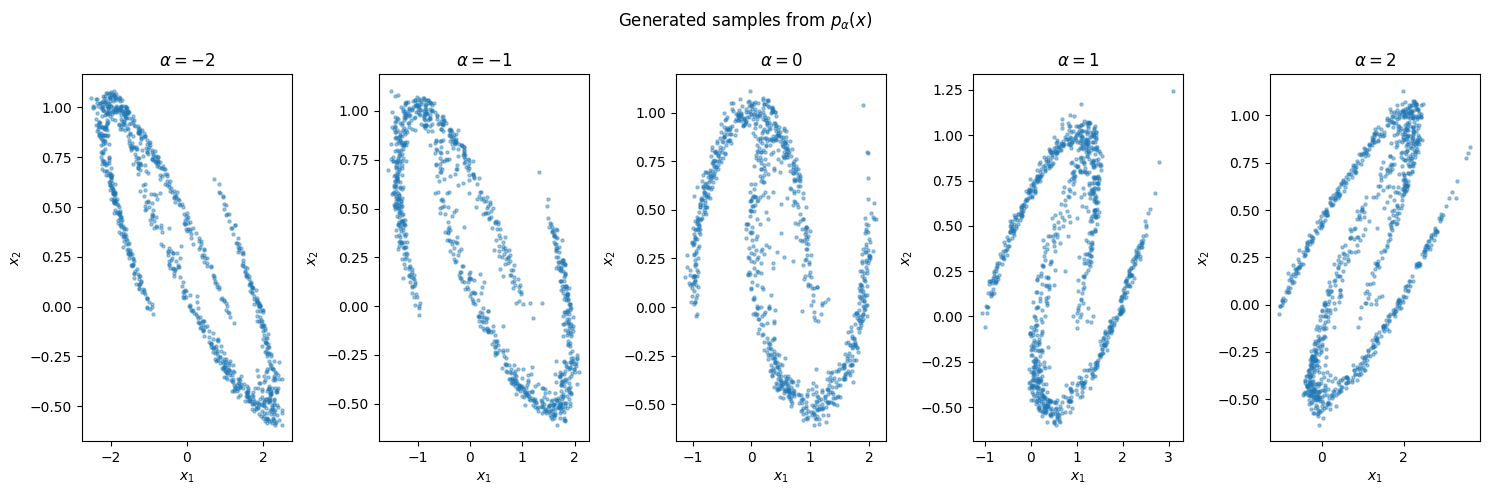

Saved figs/Figure3b.pdf


In [37]:
fig, axes = plt.subplots(1, 5, figsize=(15, 5), sharex=False, sharey=False)

for ax, a in zip(axes, alpha):
    x_np = samples[a].numpy()
    ax.scatter(x_np[:, 0], x_np[:, 1], s=5, alpha=0.4)
    ax.set_title(f"$\\alpha = {a}$")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")

fig.suptitle("Generated samples from $p_\\alpha(x)$")
fig.tight_layout()
fig.savefig("figs/Figure3b.pdf", bbox_inches="tight")
plt.show()
print("Saved figs/Figure3b.pdf")

## Q4 - Counting FLOPs

### a)

#### Assumptions/Simplifications
- Discount the operations used to apply the mask to the tensor

#### Single Coupling Layer:

**Linear(D → H): computing $h_1$**

$$h_1 = \sum_{i=1}^{D} W_{1i} \cdot x_i + b_1$$

- D multiplications ($W_{1i} \cdot x_i$)
- D-1 additions (summing the products)
- 1 addition (bias)

Total: 2D FLOPs per hidden unit

Multiply by H hidden units and B batch size: $B \cdot H \cdot 2D$

**ReLU on $h_1$**

$$h_1' = \max(0, h_1)$$

- 1 FLOP

Total across all: $B \cdot H$

**Linear(H → 2D): contribution of $h_1$ to all 2D outputs**

Each of the 2D outputsneeds H multiplications, H-1 additions, and 1 bias addition = 2H FLOPs per
output.

Total: $B \cdot 2D \cdot 2H$

**So the MLP cost per coupling layer is:**

$$B \cdot (2DH + H + 4DH) = B \cdot (6DH + H) = B \cdot H(6D + 1)$$

---

**$\tanh$ scaling on $s$ (Per Layer)**

All elements of $D$-dimensional $s$ have $\tanh$ applied

Total: $B \cdot 10D$

---

**Inverse Coupling Transform (Per Layer)**

Per hidden unit:

$$h_i = (h'_i - t_i) \cdot \exp(-s_i)$$

- D/2 subtractions ($h'_i - t_i$)
- D/2 negations ($-s_i$)
- D/2 exponentiations ($\exp$, 10 each)
- D/2 multiplications

Total:
$$
B \cdot (\frac{D}{2} + \frac{D}{2} + \frac{D}{2} + \frac{10D}{2}) = B \cdot \frac{D}{2} \cdot 13
$$

---

**Log Determinant (Per Layer)**

$$\log|\det J^{-1}| = -\sum_{i=1}^{D/2} s_i$$

- D/2 - 1 additions (summing the s values)
- 1 negation

Total: $B \cdot D/2$ per coupling layer.

---

**Base Log Density**

- $20B$

---

**Final Log Prob Summation**

$$\log p(x) = \log p(z) + \sum_{k=1}^{K} \log|\det J_k^{-1}|$$

- 1 addition of $\log p(z) + \sum_{k=1}^{K}$
- $K-1$ additions in $\sum_{k=1}^{K} \log|\det J_k^{-1}|$

Total: $B \cdot K$

